# 01 - Análisis Exploratorio de Datos (EDA)
En este notebook responderemos a las preguntas analíticas de negocio usando solo el conjunto de entrenamiento para evitar data leakage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv('../data/interim/train.csv')
train_df.head()

C:\Users\jg153\AppData\Local\Temp\ipykernel_17712\3890792772.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,43,1,9238,1,39,120.0,1,2,1,...,9,11,14,10,12.400000,0,13.9,-0.3,0.79,Graduate
1,1,39,1,9130,1,1,133.1,1,1,1,...,0,5,5,0,0.000000,1,12.7,3.7,-1.70,Dropout
2,1,44,1,9003,1,39,140.0,1,1,38,...,0,6,13,4,11.750000,0,15.5,2.8,-4.06,Enrolled
3,1,16,1,9070,1,1,125.0,1,1,1,...,0,6,6,6,14.500000,0,12.4,0.5,1.79,Graduate
4,1,17,1,9500,1,1,142.0,1,37,37,...,0,8,8,7,14.731429,0,10.8,1.4,1.74,Graduate


## 1. Distribución de la Variable Objetivo

In [2]:
plt.figure(figsize=(8,5))
sns.countplot(data=train_df, x='Target', order=['Dropout', 'Enrolled', 'Graduate'])
plt.title('Distribución de la Variable Objetivo')
plt.show()

<Figure size 800x500 with 1 Axes>

**Hecho**: La clase mayoritaria es Graduate, seguida de cerca por Dropout. Enrolled es la minoría.

**Interpretación**: Existe un desbalance moderado hacia Graduate/Dropout. La deserción es muy alta (casi un tercio de la muestra).

**Decisión**: Podríamos agrupar 'Enrolled' y 'Graduate' en 'No-Dropout' si queremos un problema binario de alerta, o usar enfoques multiclase con balanceo.

## 2. Condición Económica vs Deserción

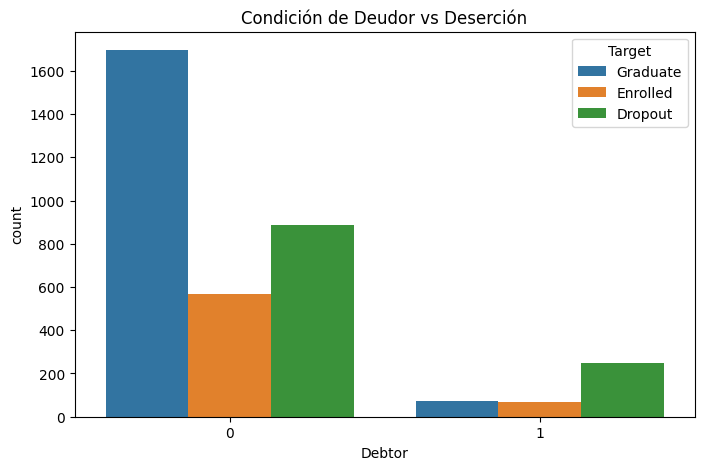

In [3]:
plt.figure(figsize=(8,5))
sns.countplot(data=train_df, x='Debtor', hue='Target')
plt.title('Condición de Deudor vs Deserción')
plt.show()

**Hecho**: Entre los estudiantes que son deudores (Debtor=1), la inmensa mayoría abandona (Dropout). Entre los no deudores, la mayoría se gradúa.

**Interpretación**: El factor económico es un predictor altísimo y crítico de abandono.

**Decisión**: Esta variable se mantendrá y podría tener mucha importancia en el modelo.

## 3. Rendimiento en 1er Semestre

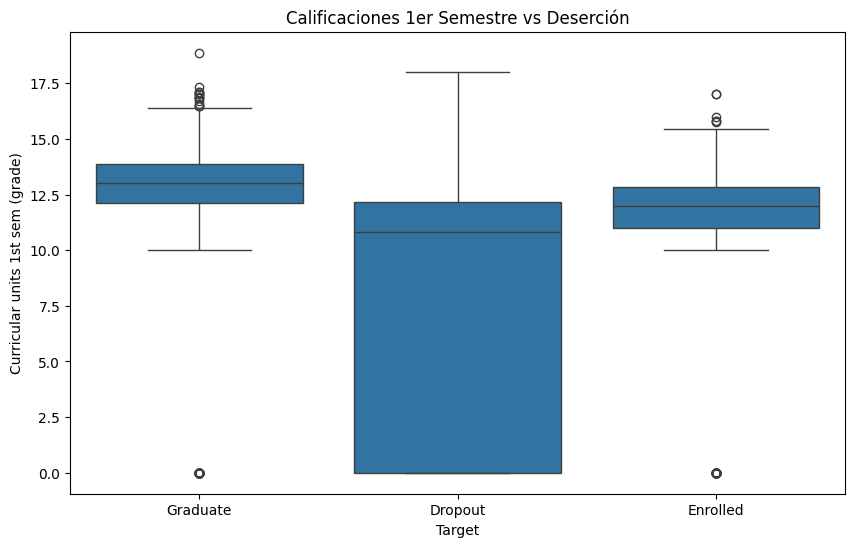

In [4]:
plt.figure(figsize=(10,6))
sns.boxplot(data=train_df, x='Target', y='Curricular units 1st sem (grade)')
plt.title('Calificaciones 1er Semestre vs Deserción')
plt.show()

**Hecho**: Los que abandonan tienen una mediana de notas drásticamente menor (muchos con nota 0). Los graduados tienen notas más altas y concentradas.

**Interpretación**: El éxito inicial predice el éxito final. Las notas de 0 podrían representar abandono temprano (estudiantes que se matricularon pero no rindieron exámenes).

**Decisión**: Esta característica será central. Debemos revisar si las notas 0 representan verdaderos ceros o NAs semánticos de quienes nunca asistieron.